# Day 2 Project: 중고차 가격 데이터
-  "중고차 가격 예측 모델"이나 "중고차 특성에 따른 클러스터링"을 가정하여 데이터를 준비한다.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

car_df = pd.read_csv('data/cars.csv')
brand_df = pd.read_csv('data/brand.csv')

In [27]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB


In [28]:
car_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [29]:
car_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [30]:
brand_df.shape

(48, 2)

In [31]:
brand_df.describe()

,title,country
count,48,48
unique,48,12
top,skoda,Japan
freq,1,11


In [15]:
brand_df.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


## 1. cars.csv와 brand.csv의 데이터 합치기

In [ ]:
df_working = car_df.copy() # 원본 보호를 위한 복사본 생성

In [52]:
# brand_df 컬럼명 정리
brand_df.columns = ['brand', 'country']
# brand_df의 브랜드명도 대문자+공백제거
brand_df['brand'] = brand_df['brand'].str.upper().str.strip() #"이 글자들을 모두 대문자로 바꾸고, 혹시 모를 앞뒤 빈칸도 깔끔하게 지워서 brand라는 새 칸에 저장해."

# "제목(title) 칸에 있는 글자들을 딱 첫 번째 공백(' ')에서만 반으로 쪼개서, 두 개의 새로운 열을 가진 임시 표(split_data)를 만들어줘."
split_data = df_working['title'].str.split(' ', n=1, expand=True)   # n=1: "공백이 여러 개 있어도 상관 말고, 맨 앞에 나오는 첫 번째 공백에서만 딱 한 번 잘라!"라는 뜻입니다. (브랜드명과 모델명을 나누는 기준점)
df_working['brand'] = split_data[0].str.upper().str.strip()
df_working['model'] = split_data[1].str.upper().str.strip()
#"방금 쪼갠 것 중 왼쪽(0번) 데이터는 '브랜드'야. 이 글자들을 모두 대문자로 바꾸고, 혹시 모를 앞뒤 빈칸도 깔끔하게 지워서 brand라는 새 칸에 저장해."

In [36]:
# "자동차 목록(car_df)을 기준으로, 브랜드 이름(brand)이 일치하는 데이터를 찾아 brand_df에서 국가 정보를 가져와 왼쪽에 붙여줘. 만약 정보가 없는 브랜드라도 자동차 데이터는 지우지 말고 유지해줘."
merged_df = pd.merge(df_working, brand_df, on='brand', how='left')
merged_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,model,index,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA,FABIA,0,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,CORSA,1,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,I30,2,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI,HATCH,3,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,CORSA,1,United Kingdom


In [47]:
# 결합 (how='left')
merged_df = pd.merge(df_working, brand_df, on='brand', how='left')
merged_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,model,index,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN,SKODA,FABIA,0,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,CORSA,1,United Kingdom
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,I30,2,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full,MINI,HATCH,3,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,CORSA,1,United Kingdom


## 3. 결측치 처리하기

#### 1. 'Previous Owners'


In [48]:
merged_df.isnull().sum()

title                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners      1411
Fuel type               0
Body type               0
Engine                 45
Gearbox                 0
Doors                  25
Seats                  35
Emission Class         87
Service history      3147
brand                   0
model                   0
index                   0
country                 0
dtype: int64

In [49]:
#Previous Owners      1411
merged_df['Previous Owners'].describe()

count    2276.000000
mean        2.807557
std         1.546028
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: Previous Owners, dtype: float64

In [50]:
merged_df['Previous Owners'].value_counts(dropna=False)

Previous Owners
NaN    1411
2.0     594
1.0     523
3.0     475
4.0     360
5.0     208
6.0      60
7.0      39
8.0      12
9.0       5
Name: count, dtype: int64

In [51]:
######## 결측치가 많은 'Previous Owners'는 median 값으로 대치 (평균과 median이 근사함) ########
merged_df['Previous Owners']= merged_df['Previous Owners'].fillna(merged_df['Previous Owners'].median())
merged_df['Previous Owners'].value_counts(dropna=False)

Previous Owners
3.0    1886
2.0     594
1.0     523
4.0     360
5.0     208
6.0      60
7.0      39
8.0      12
9.0       5
Name: count, dtype: int64

#### 2. Engine

In [52]:
merged_df['Engine'].value_counts(dropna=False)


Engine
1.6L    736
2.0L    553
1.2L    521
1.4L    421
1.0L    326
1.5L    294
1.3L    170
1.8L    158
3.0L     79
2.2L     75
2.1L     63
NaN      45
1.1L     39
1.7L     35
2.5L     33
1.9L     31
2.4L     28
0.9L     15
2.7L     11
3.5L     10
3.2L      7
3.7L      5
4.4L      5
2.6L      4
2.3L      4
4.2L      4
2.8L      3
5.0L      3
0.8L      2
4.3L      2
3.1L      1
3.3L      1
5.5L      1
4.8L      1
6.3L      1
Name: count, dtype: int64

In [53]:
# 데이터 정제: 'L' 제거 후 실수(float) 타입으로 변환
# keyword argument인 regex=False를 사용하여 단순 문자열 치환임을 명시
merged_df['Engine'] = merged_df['Engine'].str.replace('L', '', regex=False).astype(float)
merged_df.head()


,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,model,index,country
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4,Manual,5.0,5.0,Euro 6,NaN,SKODA,FABIA,0,Czech Republic
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,CORSA,1,United Kingdom
2,HYUNDAI I30,949,137000,2011,3.0,Petrol,Hatchback,1.4,Manual,5.0,5.0,Euro 5,NaN,HYUNDAI,I30,2,South Korea
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4,Manual,3.0,4.0,Euro 4,Full,MINI,HATCH,3,United Kingdom
4,VAUXHALL CORSA,1000,85000,2013,3.0,Diesel,Hatchback,1.3,Manual,5.0,5.0,Euro 5,NaN,VAUXHALL,CORSA,1,United Kingdom


In [54]:
merged_df['Engine'].describe()

count    3642.000000
mean        1.606260
std         0.486584
min         0.800000
25%         1.300000
50%         1.600000
75%         1.900000
max         6.300000
Name: Engine, dtype: float64

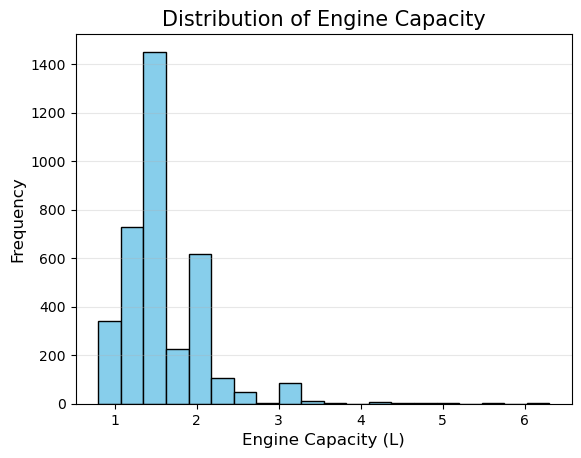

In [85]:
plt.hist(merged_df['Engine'].dropna(), bins=20, color='skyblue', edgecolor='black')

# 2. 그래프 제목 및 축 이름 설정 (키워드 인자 활용)
plt.title('Distribution of Engine Capacity', fontsize=15)
plt.xlabel('Engine Capacity (L)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 3. 그리드 추가
plt.grid(axis='y', alpha=0.3)

# 4. 그래프 출력 또는 저장
plt.savefig('engine_histogram.png')

In [55]:
merged_df['Engine'].isnull().sum()

np.int64(45)

In [56]:
merged_df['Engine'].isnull().mean()  #1.2퍼센트에 해당하는 결측치를 어떻게 할지?

np.float64(0.012205044751830757)

In [89]:
# 'Engine' 컬럼이 비어 있는 데이터들만 모아서 별도의 데이터프레임으로 보기

# 'Engine' 컬럼이 NaN인 데이터만 필터링하여 따로 저장
engine_na_rows = merged_df[merged_df['Engine'].isna()]

# 상위 10개만 출력해서 살펴보기
print(engine_na_rows.head(45))

                   title     brand      model  Price  Mileage(miles)  \
679         BMW 3 SERIES       BMW   3 SERIES   4200           68060   
835        TOYOTA MARK X    TOYOTA     MARK X   7500           77000   
856         NISSAN CUBIC    NISSAN      CUBIC   4500           47000   
1087             AUDI A1      AUDI         A1   7995           50500   
1304        MAZDA MAZDA6     MAZDA     MAZDA6   1500          155670   
1429          FORD FOCUS      FORD      FOCUS   1895          109000   
1533          CITROEN C1   CITROEN         C1   3900           71000   
1619             FORD KA      FORD         KA   2490           68837   
2022             AUDI A3      AUDI         A3   5750          139225   
2136        TOYOTA PRIUS    TOYOTA      PRIUS   8950           66000   
2194         MAZDA MX-30     MAZDA      MX-30  13899           13865   
2288         NISSAN LEAF    NISSAN       LEAF   5390           60695   
2299         NISSAN LEAF    NISSAN       LEAF   5390           6

In [58]:
###### 다른 결측치도 빠져 있어서, 45개 데이터를 제외하기로 함. ######

merged_df.dropna(subset=['Engine'], inplace=True)
print(merged_df['Engine'].isnull().sum()) 


0


#### 3. Doors

In [59]:
merged_df['Doors'].value_counts(dropna=False)

Doors
5.0    2310
3.0     734
4.0     367
2.0     216
NaN      15
Name: count, dtype: int64

In [60]:
merged_df= merged_df.dropna(subset=['Doors'], axis=0)   #### Seats수로 Doors 수를 유추하기에는 무리가 있어서, 나머지 10개도 제거함
merged_df['Doors'].isnull().sum()

np.int64(0)

#### 4. Seats

In [61]:
merged_df['Seats'].value_counts(dropna=False)

Seats
5.0    2928
4.0     529
7.0     120
2.0      24
NaN      20
6.0       4
3.0       2
Name: count, dtype: int64

In [118]:
merged_df[merged_df['Seats'].isna()]

,title,brand,model,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,country
8,VOLVO 740,VOLVO,740,750,225318,2025,3.0,Petrol,Estate,2.3,Automatic,5.0,NaN,NaN,NaN,Sweden
107,CITROEN XM,CITROEN,XM,3250,126000,1995,4.0,Diesel,Hatchback,2.5,Manual,5.0,NaN,Euro 2,NaN,France
229,MERCEDES-BENZ 260,MERCEDES-BENZ,260,2995,57400,1991,3.0,Petrol,Saloon,2.6,Automatic,4.0,NaN,NaN,NaN,Germany
237,MG MIDGET,MG,MIDGET,1875,75043,1972,3.0,Petrol,Convertible,1.3,Manual,2.0,NaN,NaN,NaN,United Kingdom
645,ROVER MINI,ROVER,MINI,1650,49309,1990,4.0,Petrol,Saloon,1.0,Automatic,2.0,NaN,NaN,NaN,United Kingdom
733,TOYOTA CAMRY,TOYOTA,CAMRY,2389,125000,1990,3.0,Petrol,Estate,2.0,Automatic,5.0,NaN,NaN,NaN,Japan
931,BMW 3 SERIES,BMW,3 SERIES,6700,105000,1999,7.0,Petrol,Coupe,2.5,Manual,2.0,NaN,Euro 2,NaN,Germany
1006,SAAB 900,SAAB,900,5995,157000,1992,5.0,Petrol,Convertible,2.0,Manual,2.0,NaN,Euro 1,NaN,Sweden
1053,VOLKSWAGEN GOLF,VOLKSWAGEN,GOLF,1250,110000,1996,3.0,Petrol,Convertible,2.0,Manual,2.0,NaN,Euro 1,NaN,Germany
1239,NISSAN SUNNY,NISSAN,SUNNY,999,60000,1985,3.0,Petrol,Saloon,1.3,Manual,4.0,NaN,NaN,NaN,Japan


In [62]:
merged_df= merged_df.dropna(subset=['Seats'], axis=0)

In [63]:
merged_df.isnull().sum()

title                   0
Price                   0
Mileage(miles)          0
Registration_Year       0
Previous Owners         0
Fuel type               0
Body type               0
Engine                  0
Gearbox                 0
Doors                   0
Seats                   0
Emission Class         14
Service history      3071
brand                   0
model                   0
index                   0
country                 0
dtype: int64

#### 5. Emission Class

In [64]:
merged_df['Emission Class'].value_counts(dropna=False)

Emission Class
Euro 5    1256
Euro 6    1109
Euro 4    1067
Euro 3     137
Euro 2      23
NaN         14
Euro 1       1
Name: count, dtype: int64

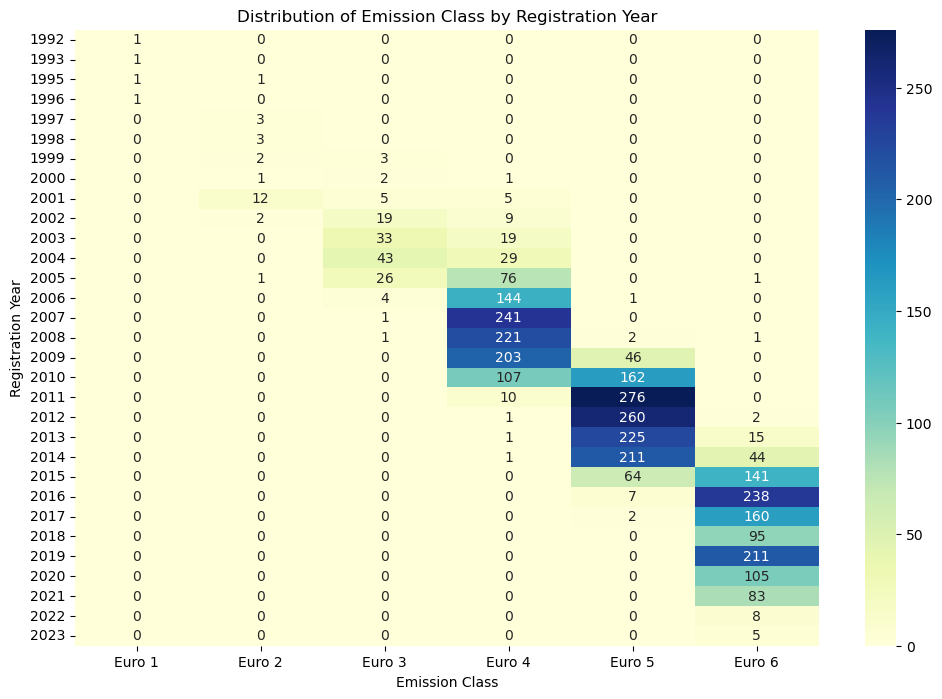

In [126]:
### Emission Class는 연식과 깊은 관계가 있다고 하여, Euro 등급과  차량 연식(Registration_Year)의 관계를 먼저 시각화 해봄 ######

# 1. 연도와 Emission Class 간의 교차 테이블 생성
emission_by_year = pd.crosstab(merged_df['Registration_Year'], merged_df['Emission Class'])

# 2. 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(emission_by_year, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Distribution of Emission Class by Registration Year')
plt.xlabel('Emission Class')
plt.ylabel('Registration Year')
plt.show()

In [65]:
# Emission Class가 NaN인 데이터들의 연도별 개수 확인
merged_df[merged_df['Emission Class'].isna()]['Registration_Year'].value_counts().sort_index()

Registration_Year
1987    1
1988    1
2008    1
2009    1
2010    1
2011    1
2012    5
2013    1
2016    1
2023    1
Name: count, dtype: int64

In [66]:
merged_df['Emission Class'].describe()

count       3593
unique         6
top       Euro 5
freq        1256
Name: Emission Class, dtype: object

In [67]:
#### 년도와 비교하여 유추하기 보다는 삭제하기로 결정함 ####
merged_df= merged_df.dropna(subset=['Emission Class'], axis=0)  

### 5. Service history

In [68]:
merged_df['Service history'].value_counts(dropna=False)

Service history
NaN     3059
Full     534
Name: count, dtype: int64

In [69]:
####### 결측치가 상당히 많으므로, Unknown/No'로 변환 ####### 

merged_df['Service history'] = merged_df['Service history'].fillna('Unknown')
merged_df['Service history'].value_counts(dropna=False)

Service history
Unknown    3059
Full        534
Name: count, dtype: int64

In [70]:
merged_df.isnull().sum()

title                0
Price                0
Mileage(miles)       0
Registration_Year    0
Previous Owners      0
Fuel type            0
Body type            0
Engine               0
Gearbox              0
Doors                0
Seats                0
Emission Class       0
Service history      0
brand                0
model                0
index                0
country              0
dtype: int64

## 2. 카테고리형 변수를 숫자 형태로 변환하기

In [71]:
### 결측치 제거 완료 확인  
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3593 entries, 0 to 3686
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3593 non-null   object 
 1   Price              3593 non-null   int64  
 2   Mileage(miles)     3593 non-null   int64  
 3   Registration_Year  3593 non-null   int64  
 4   Previous Owners    3593 non-null   float64
 5   Fuel type          3593 non-null   object 
 6   Body type          3593 non-null   object 
 7   Engine             3593 non-null   float64
 8   Gearbox            3593 non-null   object 
 9   Doors              3593 non-null   float64
 10  Seats              3593 non-null   float64
 11  Emission Class     3593 non-null   object 
 12  Service history    3593 non-null   object 
 13  brand              3593 non-null   object 
 14  model              3593 non-null   object 
 15  index              3593 non-null   int64  
 16  country            3593 non-n

### 1. 수치형 칼럼 정제 (지수 표기법 해결 및 정수화)

##### Price

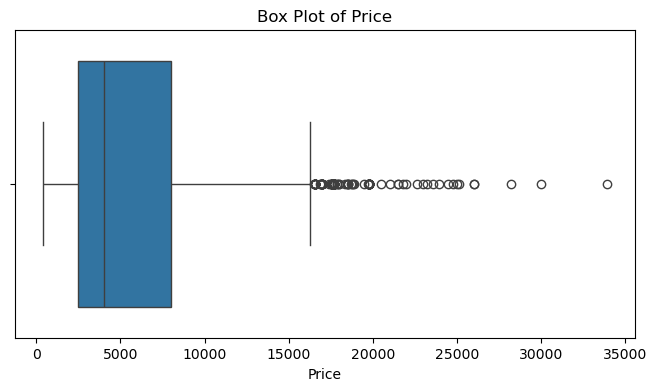

count     3593.000000
mean      5791.841637
std       4515.066997
min        400.000000
25%       2490.000000
50%       3999.000000
75%       7999.000000
max      33900.000000
Name: Price, dtype: float64


In [72]:
#Price 분포도를 그려보고 outlier 파악

# Price 박스 플롯 시각화
plt.figure(figsize=(8, 4))
sns.boxplot(x=merged_df['Price'])
plt.title('Box Plot of Price')
plt.show()

# 통계 요약 확인
print(merged_df['Price'].describe())

<Axes: xlabel='Log_Price'>

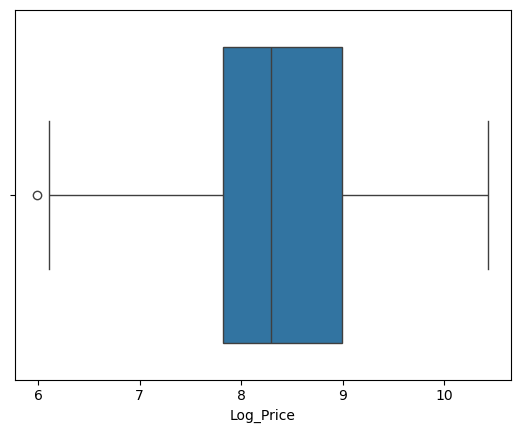

In [73]:
# 아웃라이어가 상당히 많이 존재하지만, 데이터를 삭제하는 IQR 방법 보다는 로그 변환을 시도해보자.
merged_df['Log_Price'] = np.log1p(merged_df['Price'])

# 변환 후 박스 플롯
sns.boxplot(x=merged_df['Log_Price'])

In [74]:
# 6 이하 즉, 400달러 
merged_df = merged_df[merged_df['Log_Price'] > 6]
print(f"Price 이상치 제거 후 남은 데이터: {len(merged_df)}개")

Price 이상치 제거 후 남은 데이터: 3592개


In [75]:
merged_df['Log_Price'].describe()

count    3592.000000
mean        8.375177
std         0.775215
min         6.111467
25%         7.820440
50%         8.294175
75%         8.987228
max        10.431200
Name: Log_Price, dtype: float64

In [76]:
merged_df['Price'].describe()

count     3592.000000
mean      5793.342706
std       4514.798874
min        450.000000
25%       2490.000000
50%       3999.500000
75%       7999.250000
max      33900.000000
Name: Price, dtype: float64

#### Mileage(miles) 

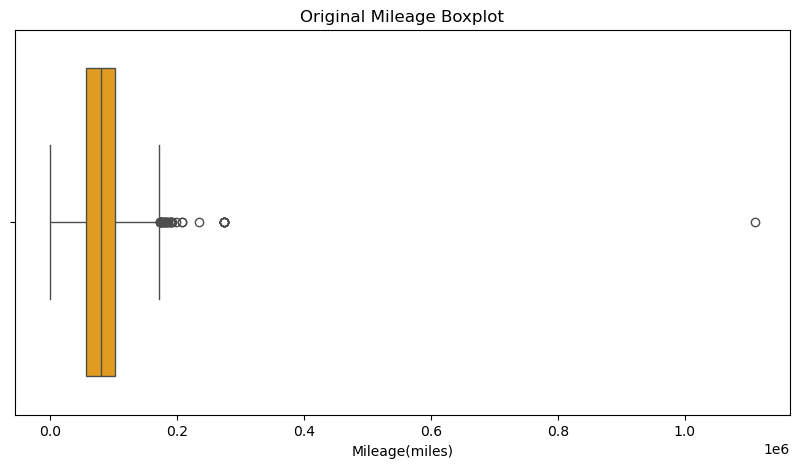

In [77]:
# Mileage(miles)  분포도를 그려보고 outlier 파악

# 2. Mileage(miles) 분포 확인 (로그 변환 전)
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_df['Mileage(miles)'], color='orange')
plt.title('Original Mileage Boxplot')
plt.show()

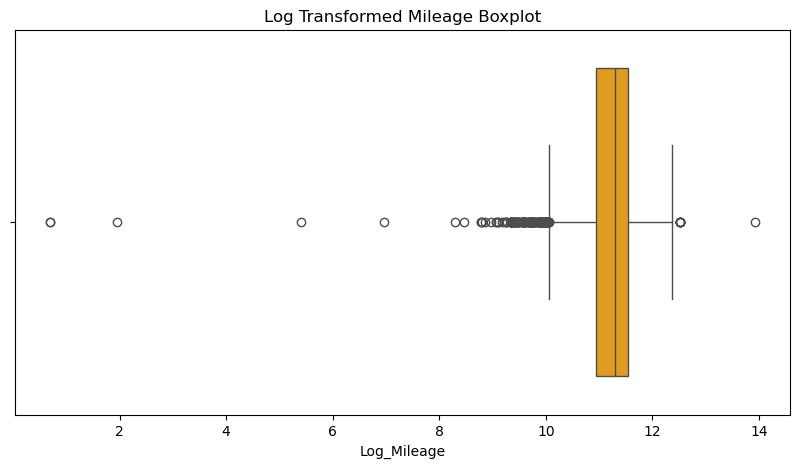

In [82]:
# 마찬가지로 로그 변환
# 마일리지는 0인 경우가 있을 수 있으므로 np.log1p (log(1+x))를 사용
merged_df['Log_Mileage'] = np.log1p(merged_df['Mileage(miles)'])



# 로그 변환 후 분포 확인
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_df['Log_Mileage'], color='orange')
plt.title('Log Transformed Mileage Boxplot')
plt.show()

In [83]:
merged_df['Mileage(miles)'].value_counts(dropna=False).sort_index()

Mileage(miles)
1          2
6          1
222        1
1048       1
4000       1
          ..
207734     1
208000     1
234680     1
274100     7
1110100    1
Name: count, Length: 1537, dtype: int64

In [84]:
merged_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,brand,model,index,country,Log_Price,Log_Mileage
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4,Manual,5.0,5.0,Euro 6,Unknown,SKODA,FABIA,0,Czech Republic,8.839422,11.158961
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2,Manual,3.0,5.0,Euro 4,Full,VAUXHALL,CORSA,1,United Kingdom,7.310550,11.391729
2,HYUNDAI I30,949,137000,2011,3.0,Petrol,Hatchback,1.4,Manual,5.0,5.0,Euro 5,Unknown,HYUNDAI,I30,2,South Korea,6.856462,11.827744
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4,Manual,3.0,4.0,Euro 4,Full,MINI,HATCH,3,United Kingdom,7.781556,11.479700
4,VAUXHALL CORSA,1000,85000,2013,3.0,Diesel,Hatchback,1.3,Manual,5.0,5.0,Euro 5,Unknown,VAUXHALL,CORSA,1,United Kingdom,6.908755,11.350418


In [86]:
# 이하인 데이터가 몇 개인지 확인
under_6 = merged_df[merged_df['Log_Mileage'] <= 6]
print(f"마일리지 400마일 이하 데이터 수: {len(under_6)}개")

# 확인 후 삭제
merged_df = merged_df[merged_df['Log_Mileage'] > 6]

마일리지 400마일 이하 데이터 수: 0개


In [87]:
# 수치형 칼럼 마무리: 정수형 변환 (float -> int)
cols_to_fix = ['Previous Owners', 'Doors', 'Seats']
merged_df[cols_to_fix] = merged_df[cols_to_fix].astype(int)

### 2. 범주형(Category) 칼럼 숫자 변환

#### 1. 단순 이진 분류 (Binary Encoding) & 원-핫 인코딩 (One-Hot Encoding)

In [88]:
# 범주가 적은 변수들 원-핫 인코딩
# drop_first=True는 다중공선성을 방지하기 위해 첫 번째 카테고리를 삭제한다.
merged_df = pd.get_dummies(merged_df, columns=['Gearbox', 'Fuel type', 'Body type'], drop_first=True)
print(merged_df.columns)

Index(['title', 'Price', 'Mileage(miles)', 'Registration_Year',
       'Previous Owners', 'Engine', 'Doors', 'Seats', 'Emission Class',
       'Service history', 'brand', 'model', 'index', 'country', 'Log_Price',
       'Log_Mileage', 'Gearbox_Manual', 'Fuel type_Diesel Hybrid',
       'Fuel type_Petrol', 'Fuel type_Petrol Hybrid',
       'Fuel type_Petrol Plug-in Hybrid', 'Body type_Convertible',
       'Body type_Coupe', 'Body type_Estate', 'Body type_Hatchback',
       'Body type_MPV', 'Body type_Pickup', 'Body type_SUV',
       'Body type_Saloon'],
      dtype='object')


In [89]:
merged_df.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,Emission Class,Service history,...,Fuel type_Petrol Hybrid,Fuel type_Petrol Plug-in Hybrid,Body type_Convertible,Body type_Coupe,Body type_Estate,Body type_Hatchback,Body type_MPV,Body type_Pickup,Body type_SUV,Body type_Saloon
0,SKODA FABIA,6900,70189,2016,3,1.4,5,5,Euro 6,Unknown,...,False,False,False,False,False,True,False,False,False,False
1,VAUXHALL CORSA,1495,88585,2008,4,1.2,3,5,Euro 4,Full,...,False,False,False,False,False,True,False,False,False,False
2,HYUNDAI I30,949,137000,2011,3,1.4,5,5,Euro 5,Unknown,...,False,False,False,False,False,True,False,False,False,False
3,MINI HATCH,2395,96731,2010,5,1.4,3,4,Euro 4,Full,...,False,False,False,False,False,True,False,False,False,False
4,VAUXHALL CORSA,1000,85000,2013,3,1.3,5,5,Euro 5,Unknown,...,False,False,False,False,False,True,False,False,False,False


## 4. Scaler 활용해보기

In [90]:
# 1. 스케일링할 수치형 칼럼 정의 
# (merged_df에 포함된 수치형 칼럼들을 리스트로 묶습니다)
numeric_cols = [
    'Price', 'Mileage(miles)', 'Registration_Year', 'Previous Owners', 
    'Engine', 'Doors', 'Seats', 'Log_Price', 'Log_Mileage'
]

# 2. 스케일러 객체 생성 및 학습/변환
scaler = StandardScaler()
# 이제 merged_df가 정의되어 있으므로 에러 없이 작동합니다!
merged_df[numeric_cols] = scaler.fit_transform(merged_df[numeric_cols])

# 3. 결과 확인 (평균 0, 표준편차 1 근처로 변했는지 확인)
print("--- 스케일링 완료된 수치형 데이터 상위 5개 ---")
display(merged_df[numeric_cols].head())

--- 스케일링 완료된 수치형 데이터 상위 5개 ---


,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,Log_Price,Log_Mileage
0,0.249830,-0.288920,0.856594,0.100040,-0.418624,0.690852,0.176226,0.602010,-0.050655
1,-0.953629,0.177223,-0.834326,0.919547,-0.830419,-1.336777,0.176226,-1.373492,0.376294
2,-1.075199,1.404029,-0.200231,0.100040,-0.418624,0.690852,0.176226,-1.960233,1.176043
3,-0.753238,0.383638,-0.411596,1.739054,-0.418624,-1.336777,-1.560863,-0.764891,0.537652
4,-1.063844,0.086381,0.222499,0.100040,-0.624521,0.690852,0.176226,-1.892664,0.300521


In [92]:
merged_df.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Engine,Doors,Seats,index,Log_Price,Log_Mileage
count,3.588000e+03,3.588000e+03,3.588000e+03,3.588000e+03,3.588000e+03,3.588000e+03,3.588000e+03,3588.000000,3.588000e+03,3.588000e+03
mean,-6.337059e-17,-1.584265e-16,5.148860e-15,1.584265e-17,-3.485382e-16,-7.129191e-17,-7.762897e-16,10.481327,-3.010103e-16,-1.980331e-15
std,1.000139e+00,1.000139e+00,1.000139e+00,1.000139e+00,1.000139e+00,1.000139e+00,1.000139e+00,8.508015,1.000139e+00,1.000139e+00
min,-1.186305e+00,-2.040910e+00,-4.004802e+00,-1.538974e+00,-1.654009e+00,-2.350592e+00,-5.035040e+00,0.000000,-2.922864e+00,-7.760581e+00
25%,-7.320856e-01,-6.235268e-01,-8.343264e-01,-7.194668e-01,-6.245213e-01,-1.336777e+00,1.762264e-01,4.000000,-7.146483e-01,-4.329399e-01
50%,-3.960967e-01,-4.031557e-02,1.113378e-02,1.000402e-01,-6.828819e-03,6.908519e-01,1.762264e-01,8.000000,-1.026821e-01,1.893231e-01
75%,4.945298e-01,5.456386e-01,8.565940e-01,1.000402e-01,6.108637e-01,6.908519e-01,1.762264e-01,17.000000,7.929548e-01,6.550423e-01
max,6.261559e+00,2.606178e+01,2.336149e+00,5.017082e+00,9.670354e+00,6.908519e-01,3.650404e+00,45.000000,2.658796e+00,5.013643e+00


#### 데이터분할

In [93]:
from sklearn.model_selection import train_test_split

# 1. 모델 학습에 사용할 최종 피처 선택 (수치화된 데이터만)
# 문자열 컬럼('title', 'brand', 'model', 'country' 등)은 제외.
X = merged_df.drop(['Price', 'Log_Price', 'title', 'brand', 'model', 'country'], axis=1)
y = merged_df['Log_Price']  # 가격 분포가 치우쳐져 있다면 Log_Price를 쓰는 게 성능에 더 좋다.

# 2. 데이터 분할 (학습용 80% : 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"전체 데이터 개수: {len(X)}")
print(f"학습용 데이터: {X_train.shape[0]}개")
print(f"테스트용 데이터: {X_test.shape[0]}개")

전체 데이터 개수: 3588
학습용 데이터: 2870개
테스트용 데이터: 718개


## 5. 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출 (PCA)


In [95]:
import numpy as np
from sklearn.decomposition import PCA

# 1. 숫자형 데이터만 자동으로 골라내기
# X_train에서 float이나 int 형태의 컬럼만 추출합니다.
X_train_numeric = X_train.select_dtypes(include=[np.number])

# 2. PCA 설정 (정보량 70% 유지)
pca = PCA(n_components=0.70)

# 3. PCA 학습 및 변환
X_train_pca = pca.fit_transform(X_train_numeric)

# 4. 결과 출력
print(f"--- PCA 결과 리포트 ---")
print(f"기존 숫자형 컬럼 개수: {X_train_numeric.shape[1]}개")
print(f"압축된 주성분 개수: {pca.n_components_}개")
print(f"보존된 정보량: {sum(pca.explained_variance_ratio_):.2%}")

--- PCA 결과 리포트 ---
기존 숫자형 컬럼 개수: 8개
압축된 주성분 개수: 1개
보존된 정보량: 91.01%


## 기본 EDA

In [107]:
# 맥 전용 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지)

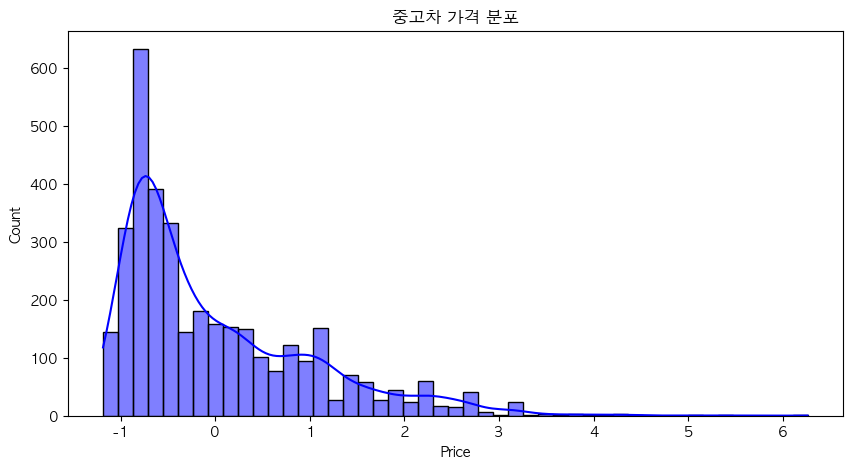

In [103]:
# 타겟 변수(Price)의 분포 확인
plt.figure(figsize=(10, 5))
sns.histplot(merged_df['Price'], kde=True, color='blue')
plt.title('중고차 가격 분포')
plt.show()

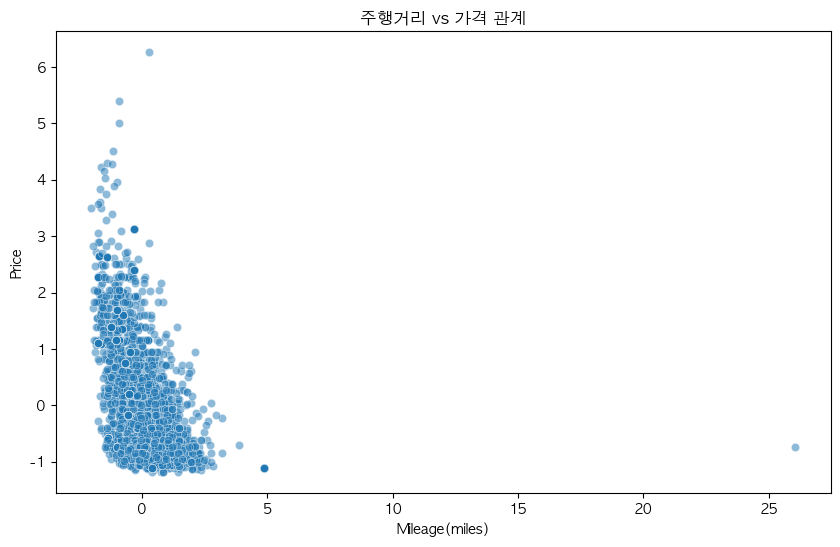

In [104]:
# 주행거리와 가격의 관계 (산점도)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='Mileage(miles)', y='Price', alpha=0.5)
plt.title('주행거리 vs 가격 관계')
plt.show()

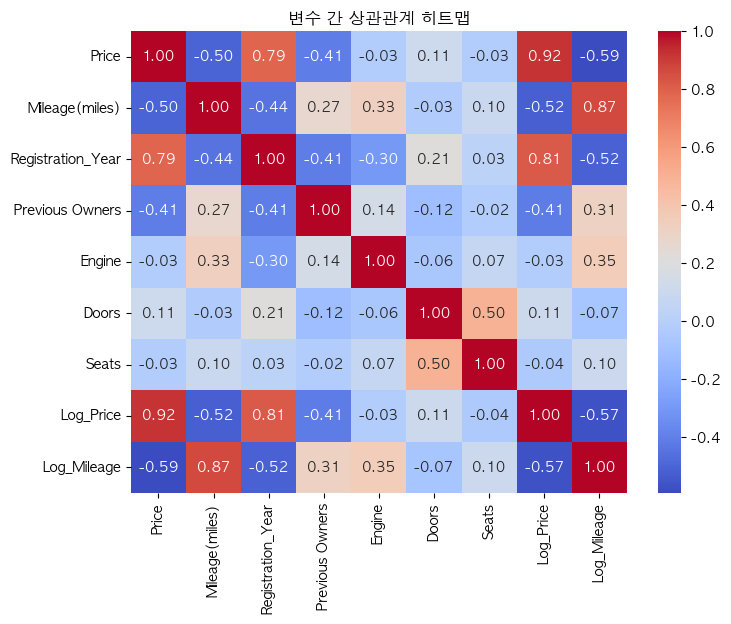

In [106]:
# 상관관계 히트맵 (Heatmap)
plt.figure(figsize=(8, 6))
# 수치형 데이터만 선택하여 상관계수 계산
corr = merged_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('변수 간 상관관계 히트맵')
plt.show()

## 국가별 총 브랜드 개수는?

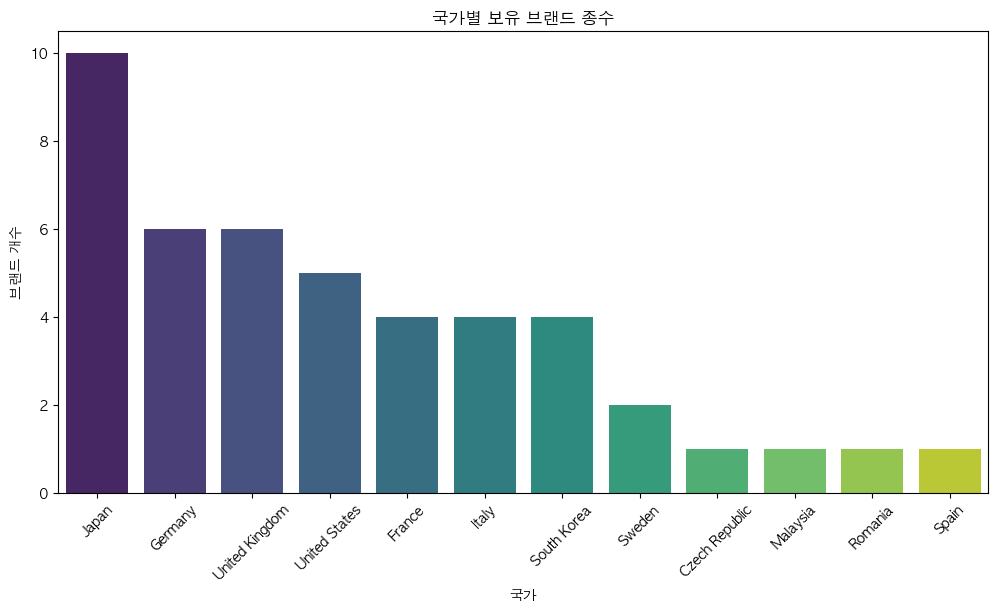

--- 국가별 브랜드 개수 상세 ---
country
Japan             10
Germany            6
United Kingdom     6
United States      5
France             4
Italy              4
South Korea        4
Sweden             2
Czech Republic     1
Malaysia           1
Romania            1
Spain              1
Name: brand, dtype: int64


In [127]:
# 국가별 브랜드 개수 시각화

# 1. 국가별 고유 브랜드 개수 계산
country_brand_counts = merged_df.groupby('country')['brand'].nunique().sort_values(ascending=False)

# 2. 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    x=country_brand_counts.index, 
    y=country_brand_counts.values, 
    hue=country_brand_counts.index, # x와 동일하게 설정
    palette='viridis', 
    legend=False                   # 범례는 숨기기
)

plt.title('국가별 보유 브랜드 종수')
plt.xlabel('국가')
plt.ylabel('브랜드 개수')
plt.xticks(rotation=45)
plt.show()

print("--- 국가별 브랜드 개수 상세 ---")
print(country_brand_counts)

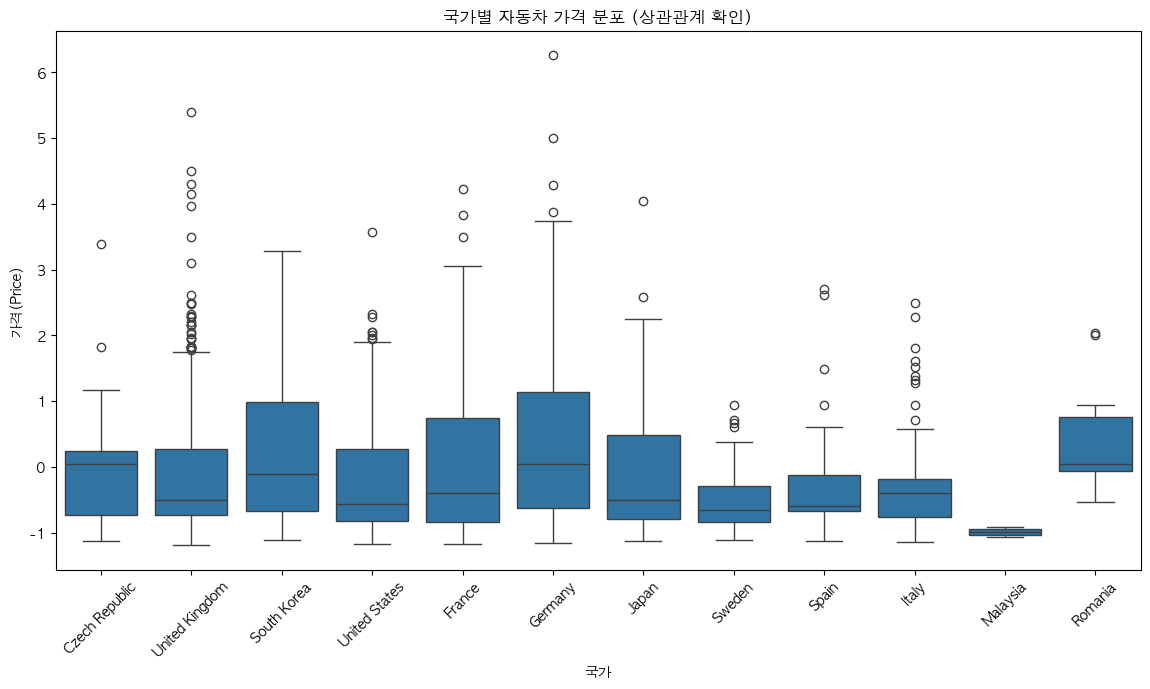

In [109]:
# 브랜드/국가와 가격의 상관관계 (Boxplot)
# 국가별 가격 분포 확인 (어느 나라 차가 비싼가?)
plt.figure(figsize=(14, 7))
sns.boxplot(data=merged_df, x='country', y='Price')

plt.title('국가별 자동차 가격 분포 (상관관계 확인)')
plt.xlabel('국가')
plt.ylabel('가격(Price)')
plt.xticks(rotation=45)
plt.show()

## 상관관계가 높은 변수들이 있는지 확인해보세요.

In [ ]:
# ===============================
#양의 상관 관계: 가격, 
#음의 상관 관계: 주행 거리, 연식

# 독일 브랜드 차량이 전반적으로 고가에 형성되어 있다는 뜻
# 영국(United Kingdom)이나 독일 그래프 위로 삐져나온 점 --> 주행거리나 연식만으로는 설명되지 않는 '초고가 희귀 매물'이 존재
# 말레이시아(Malaysia) 등 데이터 부족
# ===============================

#### VIF(분산 팽창 지수)

In [114]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. VIF를 계산할 숫자형 데이터만 선택
vif_features = [col for col in numeric_cols if col not in ['Price', 'Log_Price']]
vif_data = merged_df[vif_features].dropna()

# 2. VIF 계산
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_data.columns))]

# 3. 결과 확인
print("--- 변수별 VIF 지수 ---")
print(vif_df.sort_values(by="VIF", ascending=False))

--- 변수별 VIF 지수 ---
             feature       VIF
6        Log_Mileage  4.460808
0     Mileage(miles)  4.032755
1  Registration_Year  1.588732
4              Doors  1.415105
5              Seats  1.371746
2    Previous Owners  1.225544
3             Engine  1.175570


# 모델 학습 및 예측

## 1. 선형 회귀 vs 랜덤 포레스트 학습 및 비교

In [117]:
# 1. X_test에서도 숫자형 데이터만 골라내기 (X_train과 동일한 기준)
X_test_numeric = X_test.select_dtypes(include=[np.number])

# 2. 이미 학습된 pca 객체를 사용해서 X_test를 변환
# 주의: fit_transform이 아니라 transform만 사용해야 합니다!
X_test_pca = pca.transform(X_test_numeric)

print("X_test_pca 정의 완료!")
print(f"테스트 데이터 형태: {X_test_pca.shape}")

X_test_pca 정의 완료!
테스트 데이터 형태: (718, 1)


In [119]:
# 1. PCA 주성분 대신, 스케일링된 숫자형 원본 데이터(X_train_numeric) 사용
# 아까 만들어둔 X_train_numeric과 X_test_numeric을 그대로 사용합니다.

# 2. 모델 재학습
lr_model.fit(X_train_numeric, y_train)
rf_model.fit(X_train_numeric, y_train)

# 3. 예측
y_pred_lr_raw = lr_model.predict(X_test_numeric)
y_pred_rf_raw = rf_model.predict(X_test_numeric)

# 4. 성능 비교
print("--- 원본 수치형 데이터 학습 결과 ---")
evaluate(y_test, y_pred_lr_raw, "선형 회귀 (Raw)")
evaluate(y_test, y_pred_rf_raw, "랜덤 포레스트 (Raw)")

--- 원본 수치형 데이터 학습 결과 ---
[선형 회귀 (Raw)] R2 Score: 0.7816 | RMSE: 0.4644
[랜덤 포레스트 (Raw)] R2 Score: 0.8372 | RMSE: 0.4010


In [ ]:
# "이 차가 벤츠인가? 수동변속기인가? 디젤인가?" 같은 정보까지 랜덤 포레스트에 더하기

# 1. 모든 피처(수치형 + 원-핫 인코딩된 범주형)를 포함한 X 만들기
# X_train, X_test는 이미 원-핫 인코딩 결과가 포함된 merged_df에서 분리된 상태여야 합니다.
# 만약 아까 X_train에서 문자열만 뺐다면, 이미 준비가 된 상태일 거예요.

# 2. 랜덤 포레스트 재학습 (전체 피처 사용)
rf_model.fit(X_train_numeric, y_train) # <- 여기서 범주형이 포함된 X_train을 넣어보세요!

In [121]:
print("현재 X_train의 컬럼 개수:", len(X_train.columns))
print("--- 컬럼 목록 상위 20개 ---")
print(X_train.columns[:20])

# 2. 데이터 타입 확인 (float/int 외에 다른 게 있는지)
print("\n--- 데이터 타입 요약 ---")
print(X_train.dtypes.value_counts())

현재 X_train의 컬럼 개수: 23
--- 컬럼 목록 상위 20개 ---
Index(['Mileage(miles)', 'Registration_Year', 'Previous Owners', 'Engine',
       'Doors', 'Seats', 'Emission Class', 'Service history', 'index',
       'Log_Mileage', 'Gearbox_Manual', 'Fuel type_Diesel Hybrid',
       'Fuel type_Petrol', 'Fuel type_Petrol Hybrid',
       'Fuel type_Petrol Plug-in Hybrid', 'Body type_Convertible',
       'Body type_Coupe', 'Body type_Estate', 'Body type_Hatchback',
       'Body type_MPV'],
      dtype='object')

--- 데이터 타입 요약 ---
bool       13
float64     7
object      2
int64       1
Name: count, dtype: int64


In [122]:
# 문자열(object) 컬럼만 제외하고 모두 사용하여 학습
X_train_final = X_train.select_dtypes(exclude=['object'])
X_test_final = X_test.select_dtypes(exclude=['object'])

# 랜덤 포레스트 재학습
rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train_final, y_train)

# 예측 및 평가
y_pred_final = rf_final.predict(X_test_final)
final_r2 = r2_score(y_test, y_pred_final)

print(f"최종 모델 결정계수 (R2 Score): {final_r2:.4f}")

최종 모델 결정계수 (R2 Score): 0.8447


## 예측 시스템

#### 1. 테스트 데이터 실제 가격으로 복원 및 오차 확인

In [123]:
# 1. 모델 예측 (로그값)
y_pred_log = rf_final.predict(X_test_final)

# 2. 로그값 -> 실제 가격으로 복원 (지수 함수 exp 사용)
# 만약 로그 변환 시 log1p(x+1)를 썼다면 expm1을, log를 썼다면 exp를 사용합니다.
y_test_original = np.exp(y_test)
y_pred_original = np.exp(y_pred_log)

# 3. 데이터프레임으로 결과 비교
comparison_df = pd.DataFrame({
    '실제 가격': y_test_original,
    '예측 가격': y_pred_original,
    '오차(Difference)': y_test_original - y_pred_original
})

print("--- 실제 가격 기준 예측 결과 (상위 5개) ---")
print(comparison_df.head())

--- 실제 가격 기준 예측 결과 (상위 5개) ---
         실제 가격     예측 가격  오차(Difference)
3470  0.253221  0.200244        0.052978
3019  3.731718  3.601832        0.129886
2632  0.976244  0.480730        0.495514
201   0.607821  0.585301        0.022520
3661  0.366357  0.371380       -0.005023


### 2. 가상의 자동차 가격 예측해보기


In [ ]:

# 새로운 데이터 (예시: 2022년식, 주행거리 10,000마일, 엔진 2.0 등)
# 주의: 학습 시 사용했던 X_train_final의 컬럼 순서와 정확히 일치해야 합니다.
sample_car = X_test_final.iloc[[0]].copy() # 테스트 데이터 중 하나를 샘플로 추출

# 모델에게 물어보기
predicted_log_price = rf_final.predict(sample_car)
predicted_real_price = np.exp(predicted_log_price)

print(f"🚗 이 자동차의 예측 가격은 약 {predicted_real_price[0]:.2f} 입니다.")

🚗 이 자동차의 예측 가격은 약 0.20 입니다.


### 3.정확도 시각화

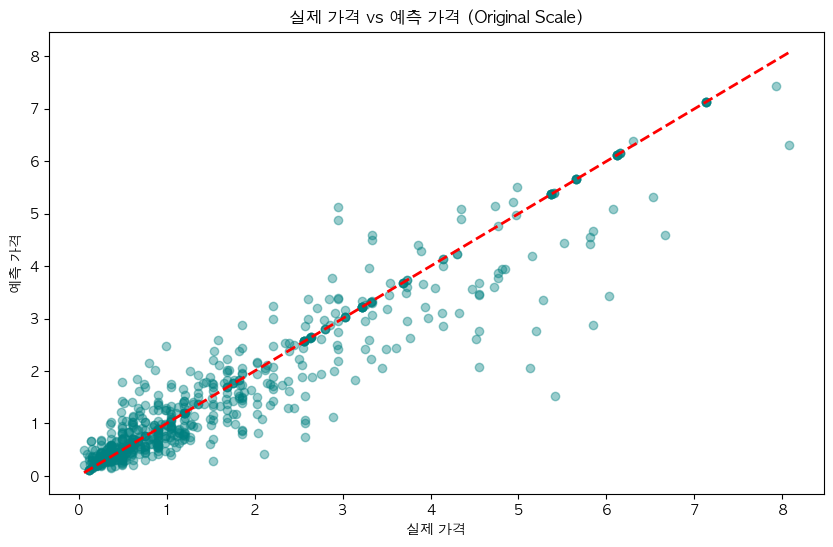

In [126]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.4, color='teal')
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 'r--', lw=2)

plt.title('실제 가격 vs 예측 가격 (Original Scale)')
plt.xlabel('실제 가격')
plt.ylabel('예측 가격')
plt.show()

In [ ]:
## 이상 ###